<figure>
    <img src="pictures/ML_process.png" alt="Description" width="1000">
    <figcaption>The Machine Learning Process</figcaption>
</figure>

## 1. Data Collection
Data Collection entails gathering (or availing) relevant data from various sources.

### Principles of Good Data Collection
In Machine Learning, the principle of Garbage-In-Garbage-Out is key. Thus, the following considerations must be made when selecting data for a machine learning exercise:

* **Accuracy** - If data is inaccurate, the algorithm's future predictions cannot be trusted. 
* **Relevance** - The type of data we collect to explain an observation should be relevant in explaining the label/response associated with the observation. Including uselss features or excluding critical features would have an adverse impact on the effectiveness of a model that tries to predict a certain outcome. Preliminary domain understanding therefore becomes critical to effectively assess data relevance.
* **Quantity** - The amount of data needed to successfully train a model depends on the type of machine learning approach chosen. This is a third consideration, quantity. Some machine learning algorithms work well with little data while others require a large amount of data to provide meaningful results. Understand the characteristics of the machine learning algorithm we intend to use can provide us with guidance on how much data we need to collect.
* **Variability** - Variability in the data is critical to facilitate our model  to gain a broader understanding of how the features affect the outcome.
* **Ethics** - There are several ethical issues to consider during the data collection process. They include privacy, security, informed consent, and bias. It is important that processes and mitigating steps be put in place to address these issues as part of the process of acquiring ground truth data.

**NB**:- If bias exists in the data used to train a model, then the model would also replicate the bias in its predictions. As one can imagine, bias predictions could prove quite harmful, especially in situations where unfavorable decisions are being made based on a machine learning model. Bias in ground truth data is often non-intentional. It sometimes stems from implicit human bias in the data collection process or from the absence of existing data on certain subpopulations. Let's recap. The data we collect for machine learning should be accurate and relevant. We must ensure that we have enough data and that the data we capture is different and captures different use cases. Finally, we must be ethical in how we collect, manage, and use data.

### Loading the Data
Use Pandas library to load and preview the data. This sets the foundation for Exploratory Data Analysis for comprehensive data understanding.
Proactively, we can load all other libraries we suspect will be relevant in our project. 

In [9]:
#Load the requisite libraries
#Load the data
#Preview the data

import pandas as pd
import seaborn as sns #To Facilitate visualizations
import matplotlib.pyplot as plt #To facilitate visualizations
import numpy as np #To facilitate mathematical calculations
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from scipy.stats import linregress
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score

data = pd.read_csv("data/churn.csv")


In [ ]:
data.info() #Check the data composition

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

There doesn't seem to be any missing data since all the columns have the same number of non-null entries

In [12]:
data.describe(include='object')

,state,phone number,international plan,voice mail plan
count,3333,3333,3333,3333
unique,51,3333,2,2
top,WV,382-4657,no,no
freq,106,1,3010,2411


In [14]:
data.describe()

,account length,area code,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,101.064806,437.182418,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856
std,39.822106,42.371290,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491
min,1.000000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,408.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000
50%,101.000000,415.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,510.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


## 2. Data Exploration
Data exploration entails analyzing data to understand its:
* Structure
* Patterns
* Potential issues e.g. missing data (density/sparsity), inconsistent data or duplicated data

### Features Identification

In [3]:
bikes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   temperature  731 non-null    float64
 1   humidity     731 non-null    float64
 2   windspeed    731 non-null    float64
 3   rentals      731 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 23.0 KB


### Features Statistical Summaries


For non-numeric features, describe the following are described:
<figure>
    <img src="pictures/non_numeric_describe.png" alt="Description" width="400">
    <figcaption>Statistical Summary for Non-Numeric Features</figcaption>
</figure>

For numeric features, describe the following are described:
<figure>
    <img src="pictures/numeric_describe.png" alt="Description" width="400">
    <figcaption>Statistical Summary for Non-Numeric Features</figcaption>
</figure>

#### Numeric Feature Summary


##### Example 1: All the data is Numerical
Obtain the numerical statistical summaries for all the features.

In [4]:
bikes.describe()

,temperature,humidity,windspeed,rentals
count,731.000000,731.000000,731.000000,731.000000
mean,59.509553,0.486937,9.238886,4504.348837
std,15.486114,0.185415,3.379815,1937.211452
min,22.602432,0.000000,0.932208,22.000000
25%,46.117264,0.353548,6.863568,3152.000000
50%,59.758972,0.502227,9.503508,4548.000000
75%,73.048236,0.624671,11.814559,5956.000000
max,90.497028,0.972500,21.126627,8714.000000


##### Example 2: Some of the Features are Categorical
Explore **Group-Level** aggregations

In [5]:
import pandas as pd
washers = pd.read_csv("washers.csv")
washers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261 entries, 0 to 260
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             261 non-null    int64  
 1   BrandName      261 non-null    object 
 2   ModelNumber    261 non-null    object 
 3   UPC            261 non-null    object 
 4   Configuration  261 non-null    object 
 5   Features       202 non-null    object 
 6   Market         261 non-null    object 
 7   Volume         261 non-null    float64
 8   IMEF           261 non-null    float64
 9   MinimumIMEF    261 non-null    float64
 10  EnergyUse      261 non-null    int64  
 11  IWF            261 non-null    float64
 12  MaximumIWF     261 non-null    float64
 13  WaterUse       261 non-null    int64  
 14  DateAvailable  261 non-null    object 
 15  DateCertified  261 non-null    object 
 16  Countries      261 non-null    object 
 17  MostEfficient  261 non-null    object 
dtypes: float64

In [6]:
washers.head()

,ID,BrandName,ModelNumber,UPC,Configuration,Features,Market,Volume,IMEF,MinimumIMEF,EnergyUse,IWF,MaximumIWF,WaterUse,DateAvailable,DateCertified,Countries,MostEfficient
0,2342279,GE,GTW845C*N***,1,Top Load,"Gentle Cycle,Delayed Start,Sanitize Option",Residential,5.0,2.06,1.29,192,4.3,8.4,6368,8/5/19,7/31/19,"United States, Canada",No
1,2331684,GE,GUD27EE*N***,84691844198,Top Load,Gentle Cycle,Residential,3.9,2.06,1.29,140,4.3,8.4,4947,12/10/18,11/30/18,United States,No
2,2331685,GE,GUD27EE*N***,7.57638E+11,Top Load,Gentle Cycle,Residential,3.9,2.06,1.29,140,4.3,8.4,4947,12/10/18,11/30/18,Canada,No
3,2331687,GE,GUD27GE*N***,84691844181,Top Load,Gentle Cycle,Residential,3.9,2.06,1.29,140,4.3,8.4,4947,12/10/18,11/30/18,United States,No
4,2331686,GE,GUD37EE*N***,7.57638E+11,Top Load,Gentle Cycle,Residential,3.9,2.06,1.29,140,4.3,8.4,4947,12/10/18,11/30/18,Canada,No


In [7]:
#Statistical summary for Categorical features
washers[['BrandName','Configuration','Countries','Features','MostEfficient','ModelNumber']].describe()

,BrandName,Configuration,Countries,Features,MostEfficient,ModelNumber
count,261,261,261,202,261,261
unique,22,2,3,37,2,256
top,LG,Front Load,"United States, Canada",Other,No,GUD27EE*N***
freq,50,143,213,60,222,2


In [8]:
#Statistical summary for a numerical featurea
washers[['Volume']].describe()

,Volume
count,261.000000
mean,4.374713
std,0.965866
min,1.900000
25%,4.300000
50%,4.500000
75%,5.000000
max,6.200000


In [9]:
#Value counts for a particular categorical feature
washers[['BrandName']].value_counts()

BrandName      
LG                 50
GE                 49
Samsung            47
Kenmore            30
Whirlpool          26
Maytag             18
Electrolux          7
Bosch               4
Miele               4
Asko                4
Beko                3
Blomberg            3
Crosley             3
Midea               2
Magic Chef          2
Amana               2
Fisher & Paykel     2
Insignia            1
Inglis              1
Gaggenau            1
GE Adora            1
Haier               1
Name: count, dtype: int64

In [10]:
#Normalized Value counts for a particular categorical feature
washers[['BrandName']].value_counts(normalize = True)*100

BrandName      
LG                 19.157088
GE                 18.773946
Samsung            18.007663
Kenmore            11.494253
Whirlpool           9.961686
Maytag              6.896552
Electrolux          2.681992
Bosch               1.532567
Miele               1.532567
Asko                1.532567
Beko                1.149425
Blomberg            1.149425
Crosley             1.149425
Midea               0.766284
Magic Chef          0.766284
Amana               0.766284
Fisher & Paykel     0.766284
Insignia            0.383142
Inglis              0.383142
Gaggenau            0.383142
GE Adora            0.383142
Haier               0.383142
Name: proportion, dtype: float64

In [11]:
#Group level aggregations i.e. pivot tables
washers.groupby('BrandName')[['Volume']].mean().sort_values(by = 'Volume')

,Volume
BrandName,
Beko,2.133333
Gaggenau,2.200000
Bosch,2.200000
Miele,2.300000
Blomberg,2.300000
Fisher & Paykel,2.400000
Haier,2.400000
Asko,2.525000
Magic Chef,2.700000


In [12]:
#Show the statistical summary for different categories in a given feature
washers.groupby('BrandName')[['Volume']].agg(['mean','median','min','max']).sort_values(('Volume', 'mean'), ascending=False)

Volume                 
                     mean median  min  max
BrandName                                 
Midea            5.200000   5.20  5.2  5.2
Maytag           4.988889   4.90  4.4  6.2
Insignia         4.800000   4.80  4.8  4.8
Kenmore          4.796667   4.80  2.4  6.2
Samsung          4.729787   4.80  2.2  5.6
LG               4.596000   4.50  2.3  5.8
Whirlpool        4.453846   4.50  2.0  5.3
Crosley          4.400000   4.50  4.2  4.5
GE               4.328571   4.50  2.2  5.2
Inglis           4.300000   4.30  4.3  4.3
Amana            4.250000   4.25  4.2  4.3
GE Adora         4.200000   4.20  4.2  4.2
Electrolux       3.785714   4.30  2.4  4.4
Magic Chef       2.700000   2.70  2.7  2.7
Asko             2.525000   2.70  2.0  2.7
Fisher & Paykel  2.400000   2.40  2.4  2.4
Haier            2.400000   2.40  2.4  2.4
Blomberg         2.300000   2.50  1.9  2.5
Miele            2.300000   2.30  2.3  2.3
Gaggenau         2.200000   2.20  2.2  2.2
Bosch            2.200000   2.20  2.2  2.2
Beko             2.133333   2.00  1.9  2.5

In [13]:
#Show the statistical summary for different categories in a given feature
washers.groupby('Countries')[['Volume']].agg(['mean','median','min','max']).sort_values(('Volume', 'mean'), ascending=False)

Volume                 
                           mean median  min  max
Countries                                       
United States, Canada  4.400939    4.5  2.0  6.2
Canada                 4.338462    4.3  3.9  4.8
United States          4.228571    4.5  1.9  5.3

<Axes: >

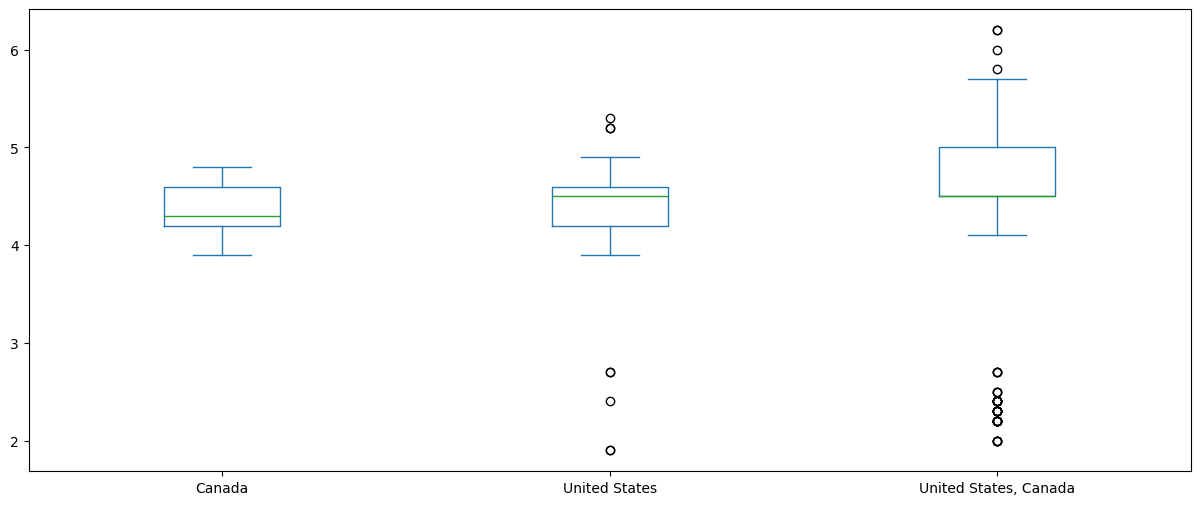

In [14]:
#Show the statistical summary for different categories in a given feature diagrammatically
washers.pivot(columns = 'Countries', values = 'Volume').plot(kind = 'box', figsize = (15, 6))

<Axes: xlabel='temperature', ylabel='rentals'>

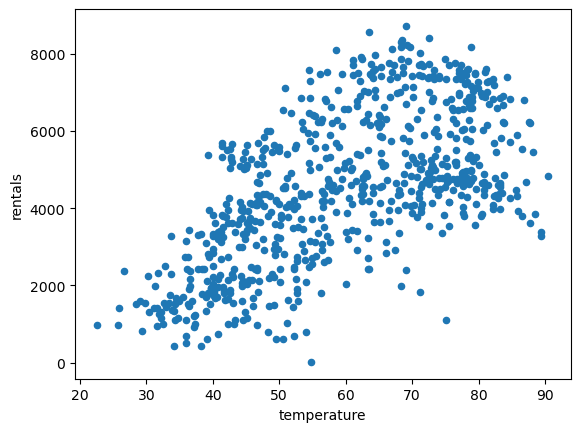

In [15]:
%matplotlib inline
bikes.plot(kind = 'scatter', x = 'temperature', y = 'rentals')

<Axes: xlabel='humidity', ylabel='rentals'>

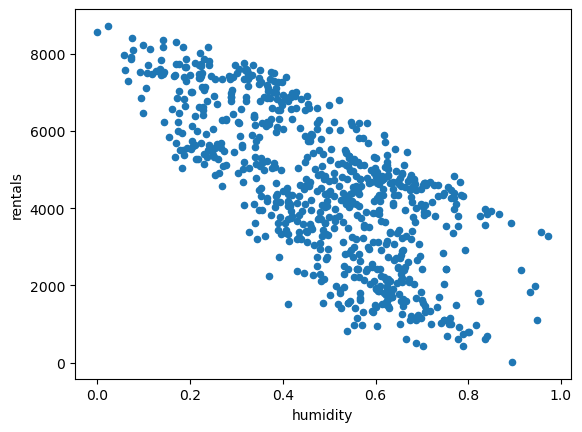

In [16]:
bikes.plot(kind = 'scatter', x = 'humidity', y = 'rentals')

<Axes: xlabel='windspeed', ylabel='rentals'>

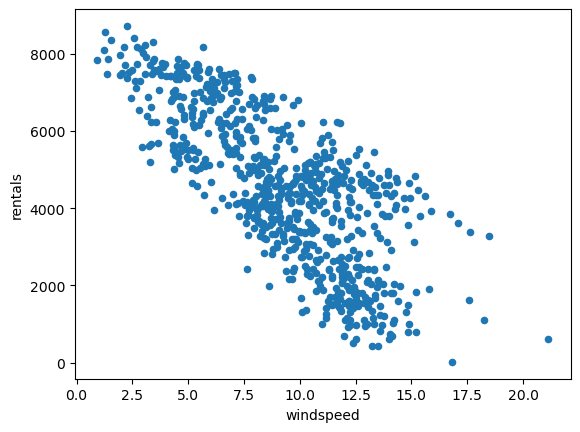

In [17]:
bikes.plot(kind = 'scatter', x = 'windspeed', y = 'rentals')

In [18]:
import pandas as pd
vehicles = pd.read_csv("vehicles.csv")
vehicles.head()

,citympg,cylinders,displacement,drive,highwaympg,make,model,class,year,transmissiontype,transmissionspeeds,co2emissions
0,14.0,6,4.1,2-Wheel Drive,19.0,Buick,Electra/Park Avenue,Large Cars,1984,Automatic,4,555.437500
1,14.0,8,5.0,2-Wheel Drive,20.0,Buick,Electra/Park Avenue,Large Cars,1984,Automatic,4,555.437500
2,18.0,8,5.7,2-Wheel Drive,26.0,Buick,Electra/Park Avenue,Large Cars,1984,Automatic,4,484.761905
3,21.0,6,4.3,Rear-Wheel Drive,31.0,Cadillac,Fleetwood/DeVille (FWD),Large Cars,1984,Automatic,4,424.166667
4,14.0,8,4.1,Rear-Wheel Drive,19.0,Cadillac,Brougham/DeVille (RWD),Large Cars,1984,Automatic,4,555.437500


### Relationship Visualization

#### Basic Relationship Visualization

Consider scatter plots, line graphs, etc

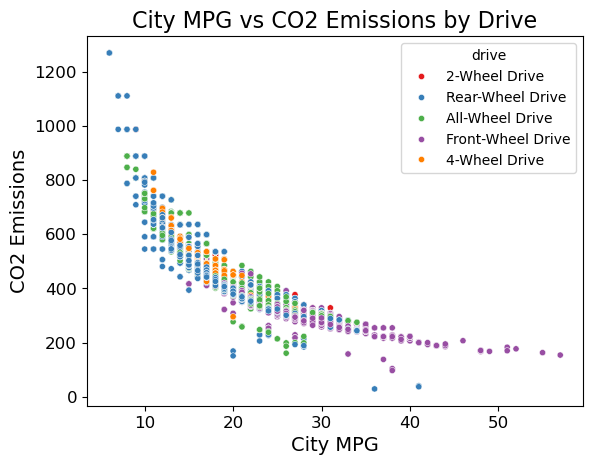

In [19]:
#E.g. scatter plot
sns.scatterplot(data=vehicles, x='citympg', y='co2emissions', hue='drive', palette='Set1', s=20)

# Add title and labels
plt.title('City MPG vs CO2 Emissions by Drive', fontsize=16)
plt.xlabel('City MPG', fontsize=14)
plt.ylabel('CO2 Emissions', fontsize=14)

# Optionally, adjust tick label sizes
plt.tick_params(axis='both', labelsize=12)

# Show plot
plt.show()

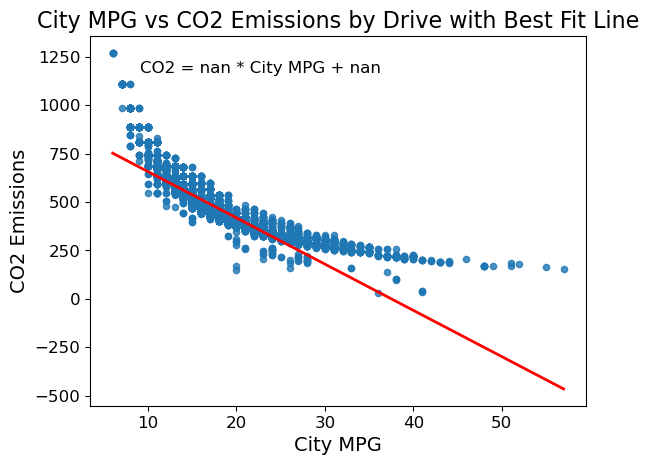

In [22]:
# Scatter plot with line of best fit using regplot
sns.regplot(data=vehicles, x='citympg', y='co2emissions', scatter_kws={'s': 20}, line_kws={'color': 'red', 'lw': 2},logistic=False, ci=None)

# Add title and labels
plt.title('City MPG vs CO2 Emissions by Drive with Best Fit Line', fontsize=16)
plt.xlabel('City MPG', fontsize=14)
plt.ylabel('CO2 Emissions', fontsize=14)

# Optionally, adjust tick label sizes
plt.tick_params(axis='both', labelsize=12)

# Calculate the line of best fit (slope, intercept)
slope, intercept, r_value, p_value, std_err = linregress(vehicles['citympg'], vehicles['co2emissions'])

# Display the equation of the line
equation = f'CO2 = {slope:.2f} * City MPG + {intercept:.2f}'
plt.text(0.1, 0.9, equation, transform=plt.gca().transAxes, fontsize=12, color='black')

# Show plot
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_27548\1533724899.py:14: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=vehicles_imputed, x='citympg', y='co2emissions', palette='Set1', s=20)
C:\Users\hp\AppData\Local\Temp\ipykernel_27548\1533724899.py:32: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=vehicles_imputed, x='citympg', y='co2emissions', palette='Set1', s=20)


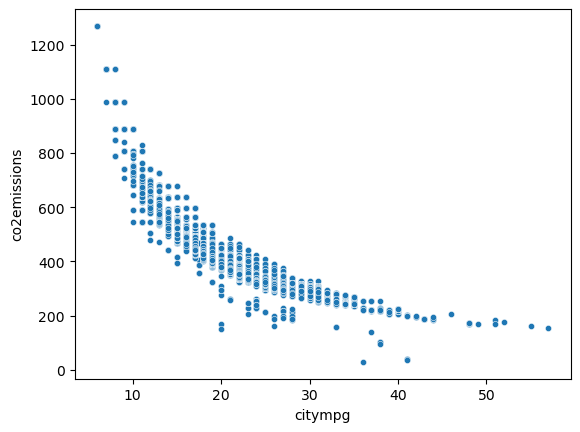

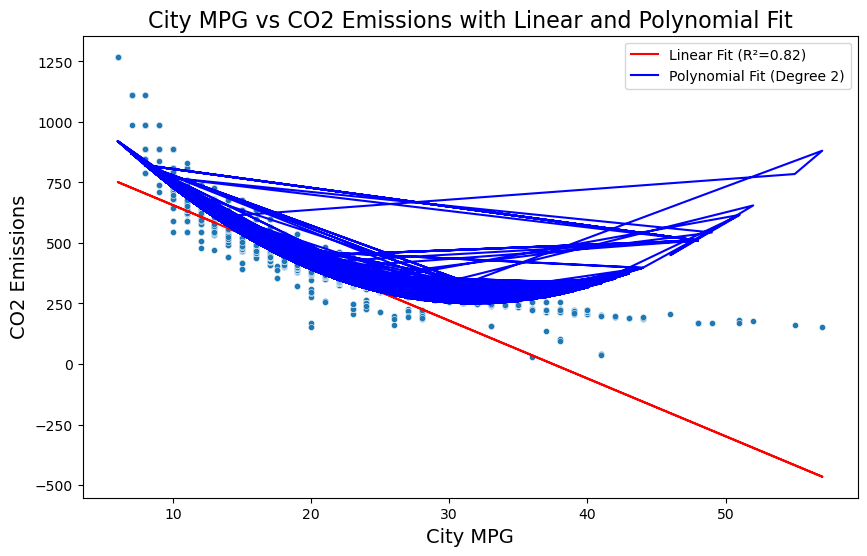

Linear Model R²: 0.822
Polynomial Model R²: 0.930


In [29]:
#Handle missing values with imputation

# Create an imputer that fills missing values with the mean
imputer = SimpleImputer(strategy='mean')

# Apply the imputer to fill missing values in the dataset
vehicles_imputed = vehicles.copy()

# Apply imputer to numerical columns (you can add more columns if needed)
numerical_columns = vehicles_imputed.select_dtypes(include=['float64', 'int64']).columns
vehicles_imputed[numerical_columns] = imputer.fit_transform(vehicles_imputed[numerical_columns])

# Now fit your model to the imputed data
sns.scatterplot(data=vehicles_imputed, x='citympg', y='co2emissions', palette='Set1', s=20)

# Fit a Linear Regression Model
linear_model = LinearRegression()
linear_model.fit(vehicles_imputed[['citympg']], vehicles_imputed['co2emissions'])
vehicles_imputed['linear_pred'] = linear_model.predict(vehicles_imputed[['citympg']])

# Fit a Polynomial Regression Model (degree 2)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(vehicles_imputed[['citympg']])
poly_model = LinearRegression()
poly_model.fit(X_poly, vehicles_imputed['co2emissions'])
vehicles_imputed['poly_pred'] = poly_model.predict(X_poly)

# Plotting the Linear and Polynomial Fit
plt.figure(figsize=(10, 6))

# Plot scatter points
sns.scatterplot(data=vehicles_imputed, x='citympg', y='co2emissions', palette='Set1', s=20)

# Plot linear fit
plt.plot(vehicles_imputed['citympg'], vehicles_imputed['linear_pred'], color='red', label=f'Linear Fit (R²={linear_model.score(vehicles_imputed[["citympg"]], vehicles_imputed["co2emissions"]):.2f})')

# Plot polynomial fit (degree 2)
plt.plot(vehicles_imputed['citympg'], vehicles_imputed['poly_pred'], color='blue', label=f'Polynomial Fit (Degree 2)')

# Add title and labels
plt.title('City MPG vs CO2 Emissions with Linear and Polynomial Fit', fontsize=16)
plt.xlabel('City MPG', fontsize=14)
plt.ylabel('CO2 Emissions', fontsize=14)
plt.legend()

# Show plot
plt.show()

# Calculate R² values for both models
linear_r2 = linear_model.score(vehicles_imputed[['citympg']], vehicles_imputed['co2emissions'])
poly_r2 = poly_model.score(X_poly, vehicles_imputed['co2emissions'])

print(f'Linear Model R²: {linear_r2:.3f}')
print(f'Polynomial Model R²: {poly_r2:.3f}')


C:\Users\hp\AppData\Local\Temp\ipykernel_27548\4220835876.py:16: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=vehicles_imputed, x='citympg', y='co2emissions', palette='Set1', s=20)


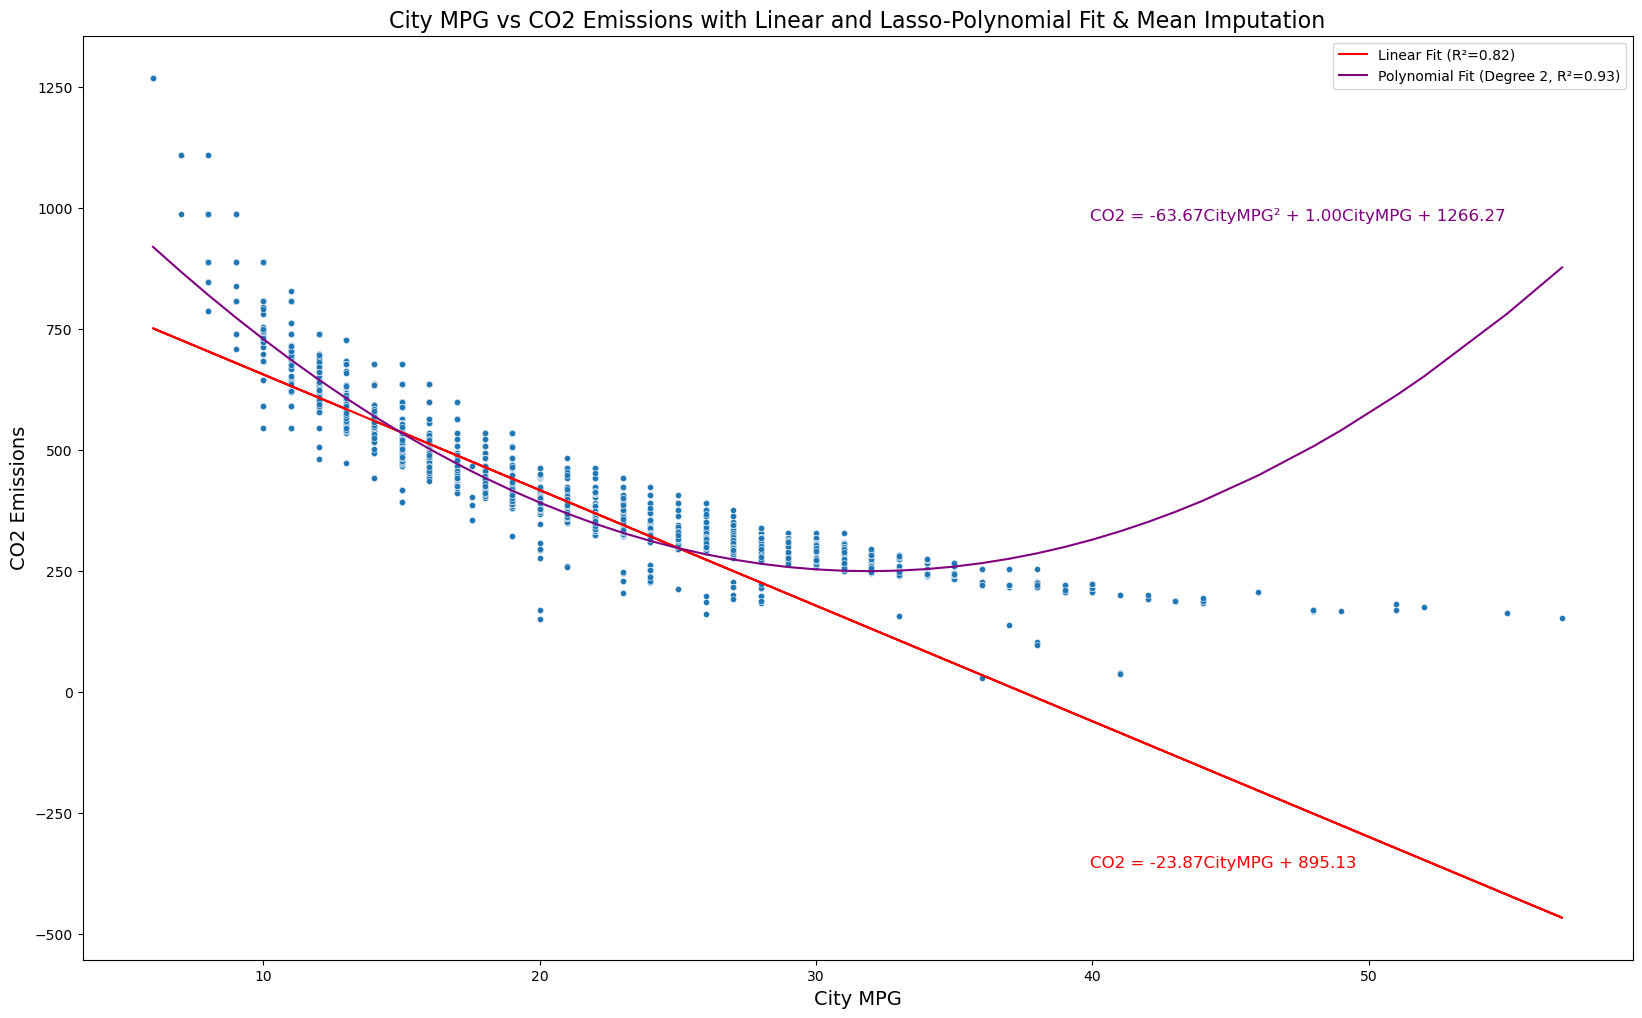

In [56]:
#Fit a line of best fit (the model) onto the scatter plot - Using Lasso Regularization



# Handle missing values with imputation
imputer = SimpleImputer(strategy='mean')

# Apply the imputer to fill missing values in the dataset
vehicles_imputed = vehicles.copy()
numerical_columns = vehicles_imputed.select_dtypes(include=['float64', 'int64']).columns
vehicles_imputed[numerical_columns] = imputer.fit_transform(vehicles_imputed[numerical_columns])

plt.figure(figsize=(20, 12))  # Set the figure size before plotting

# Scatter plot
sns.scatterplot(data=vehicles_imputed, x='citympg', y='co2emissions', palette='Set1', s=20)

# 📌 Fit a Linear Regression Model
linear_model = LinearRegression()
linear_model.fit(vehicles_imputed[['citympg']], vehicles_imputed['co2emissions'])
vehicles_imputed['linear_pred'] = linear_model.predict(vehicles_imputed[['citympg']])
linear_r2 = r2_score(vehicles_imputed['co2emissions'], vehicles_imputed['linear_pred'])

# Extract linear model coefficients
linear_slope = linear_model.coef_[0]
linear_intercept = linear_model.intercept_

# 📌 Fit a Polynomial Regression Model (degree 2) with Lasso regularization
poly_degree = 2
lasso_model = make_pipeline(PolynomialFeatures(degree=poly_degree), Lasso(alpha=0.1, max_iter=10000))
lasso_model.fit(vehicles_imputed[['citympg']], vehicles_imputed['co2emissions'])
vehicles_imputed['poly_pred'] = lasso_model.predict(vehicles_imputed[['citympg']])
poly_r2 = r2_score(vehicles_imputed['co2emissions'], vehicles_imputed['poly_pred'])

# Extract polynomial coefficients
lasso_coeffs = lasso_model.named_steps['lasso'].coef_
lasso_intercept = lasso_model.named_steps['lasso'].intercept_

# Polynomial equation: y = ax² + bx + c
a, b = lasso_coeffs[1], lasso_coeffs[2]
c = lasso_intercept

# 📌 Sort x-values for smoother polynomial plotting
sorted_indices = np.argsort(vehicles_imputed['citympg'])
sorted_x = vehicles_imputed['citympg'].iloc[sorted_indices]
sorted_poly_pred = vehicles_imputed['poly_pred'].iloc[sorted_indices]

# 📌 Plot linear fit
plt.plot(vehicles_imputed['citympg'], vehicles_imputed['linear_pred'], color='red',
         label=f'Linear Fit (R²={linear_r2:.2f})')

# 📌 Plot polynomial fit with sorted x-values (Lasso)
plt.plot(sorted_x, sorted_poly_pred, color='purple',
         label=f'Polynomial Fit (Degree {poly_degree}, R²={poly_r2:.2f})')

# 📌 Add Equations to the Plot
equation_linear = f'CO2 = {linear_slope:.2f}CityMPG + {linear_intercept:.2f}'
equation_poly = f'CO2 = {a:.2f}CityMPG² + {b:.2f}CityMPG + {c:.2f}'

plt.text(0.65, 0.10, equation_linear, transform=plt.gca().transAxes, fontsize=12, color='red')
plt.text(0.65, 0.80, equation_poly, transform=plt.gca().transAxes, fontsize=12, color='purple')

# 📌 Add title and labels
plt.title('City MPG vs CO2 Emissions with Linear and Lasso-Polynomial Fit & Mean Imputation', fontsize=16)
plt.xlabel('City MPG', fontsize=14)
plt.ylabel('CO2 Emissions', fontsize=14)
plt.legend()

# 📌 Show plot
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_27548\369766177.py:16: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=vehicles_imputed, x='citympg', y='co2emissions', palette='Set1', s=20)


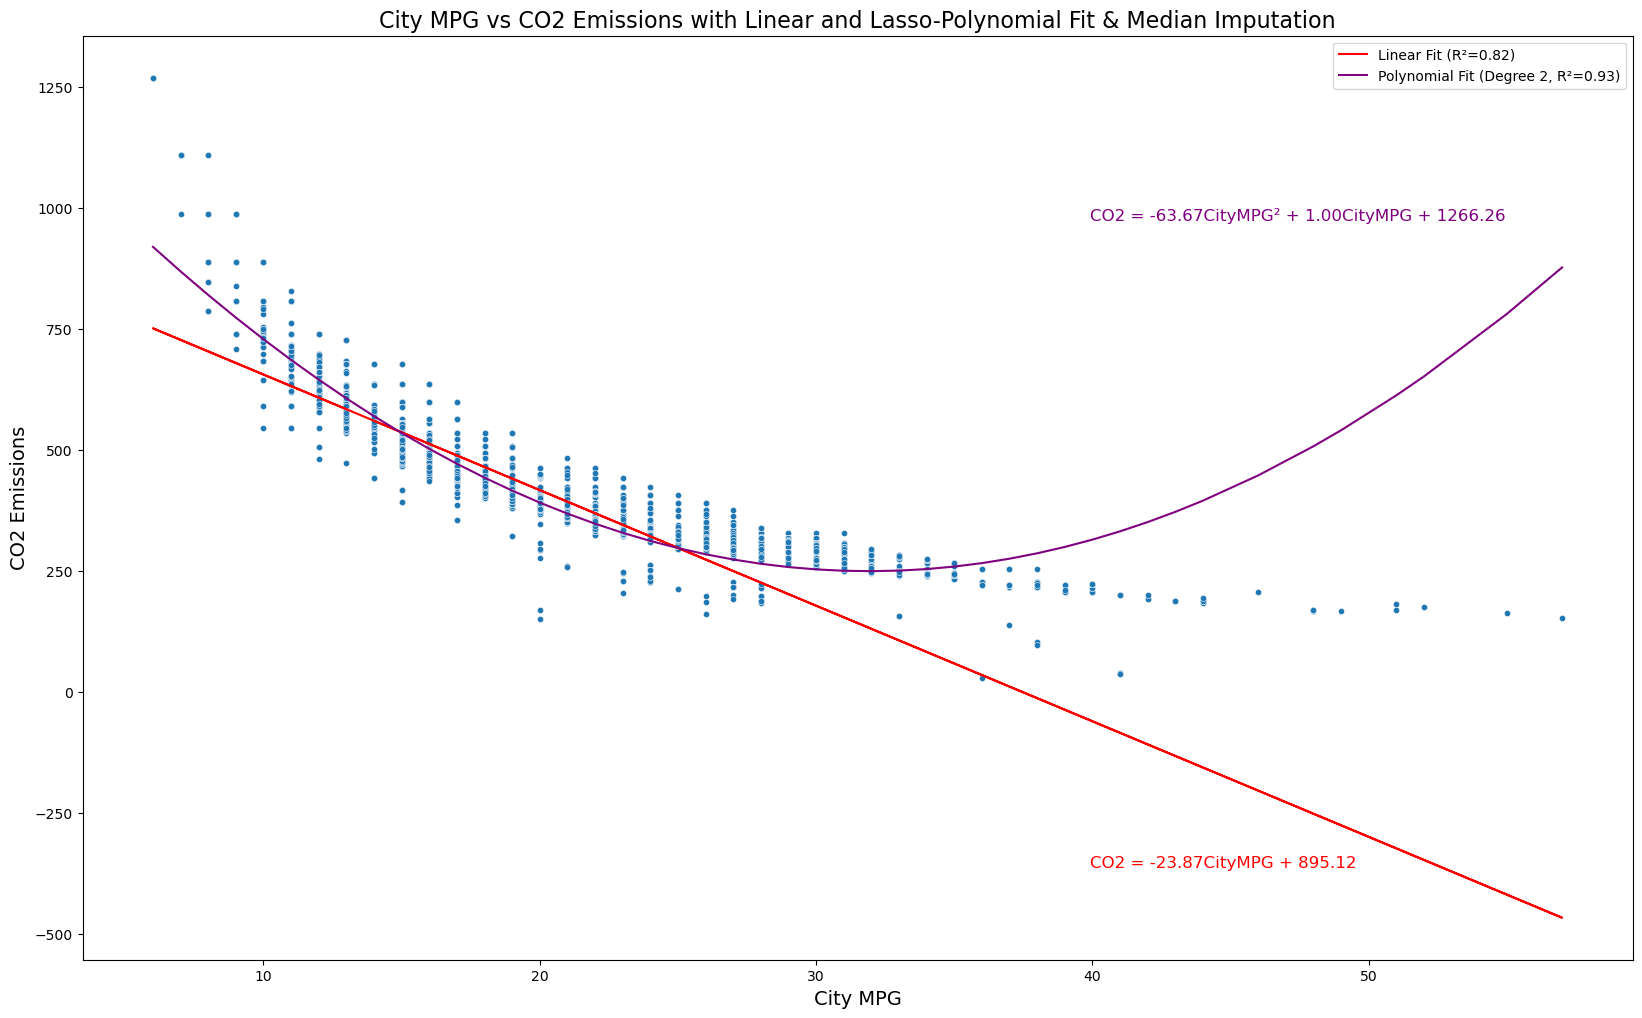

In [57]:
#Fit a line of best fit (the model) onto the scatter plot - Using Lasso Regularization and imputing with median

# Handle missing values with imputation
imputer = SimpleImputer(strategy='median')

# Apply the imputer to fill missing values in the dataset
vehicles_imputed = vehicles.copy()

# Apply imputer to numerical columns
numerical_columns = vehicles_imputed.select_dtypes(include=['float64', 'int64']).columns
vehicles_imputed[numerical_columns] = imputer.fit_transform(vehicles_imputed[numerical_columns])

plt.figure(figsize=(20, 12))  # Set the figure size before plotting

# Scatter plot
sns.scatterplot(data=vehicles_imputed, x='citympg', y='co2emissions', palette='Set1', s=20)

# Fit a Linear Regression Model
linear_model = LinearRegression()
linear_model.fit(vehicles_imputed[['citympg']], vehicles_imputed['co2emissions'])
vehicles_imputed['linear_pred'] = linear_model.predict(vehicles_imputed[['citympg']])
linear_r2 = r2_score(vehicles_imputed['co2emissions'], vehicles_imputed['linear_pred'])

# Extract linear model coefficients
linear_slope = linear_model.coef_[0]
linear_intercept = linear_model.intercept_

# Fit a Polynomial Regression Model (degree 2) with Lasso regularization
poly_degree = 2
lasso_model = make_pipeline(PolynomialFeatures(degree=poly_degree), Lasso(alpha=0.1, max_iter=10000))
lasso_model.fit(vehicles_imputed[['citympg']], vehicles_imputed['co2emissions'])
vehicles_imputed['poly_pred'] = lasso_model.predict(vehicles_imputed[['citympg']])
poly_r2 = r2_score(vehicles_imputed['co2emissions'], vehicles_imputed['poly_pred'])

# Extract polynomial coefficients
lasso_coeffs = lasso_model.named_steps['lasso'].coef_
lasso_intercept = lasso_model.named_steps['lasso'].intercept_

# Polynomial equation: y = ax² + bx + c
a, b = lasso_coeffs[1], lasso_coeffs[2]
c = lasso_intercept

# Sort x-values for smoother polynomial plotting
sorted_indices = np.argsort(vehicles_imputed['citympg'])
sorted_x = vehicles_imputed['citympg'].iloc[sorted_indices]
sorted_poly_pred = vehicles_imputed['poly_pred'].iloc[sorted_indices]

# Plot linear fit
plt.plot(vehicles_imputed['citympg'], vehicles_imputed['linear_pred'], color='red', label=f'Linear Fit (R²={linear_r2:.2f})')

# Plot polynomial fit with sorted x-values (Lasso)
plt.plot(sorted_x, sorted_poly_pred, color='purple', label=f'Polynomial Fit (Degree {poly_degree}, R²={poly_r2:.2f})')

# 📌 Add Equations to the Plot
equation_linear = f'CO2 = {linear_slope:.2f}CityMPG + {linear_intercept:.2f}'
equation_poly = f'CO2 = {a:.2f}CityMPG² + {b:.2f}CityMPG + {c:.2f}'

plt.text(0.65, 0.10, equation_linear, transform=plt.gca().transAxes, fontsize=12, color='red')
plt.text(0.65, 0.80, equation_poly, transform=plt.gca().transAxes, fontsize=12, color='purple')

# Add title and labels
plt.title('City MPG vs CO2 Emissions with Linear and Lasso-Polynomial Fit & Median Imputation', fontsize=16)
plt.xlabel('City MPG', fontsize=14)
plt.ylabel('CO2 Emissions', fontsize=14)
plt.legend()

# Show plot
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_27548\873867143.py:16: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=vehicles_imputed, x='citympg', y='co2emissions', palette='Set1', s=20)


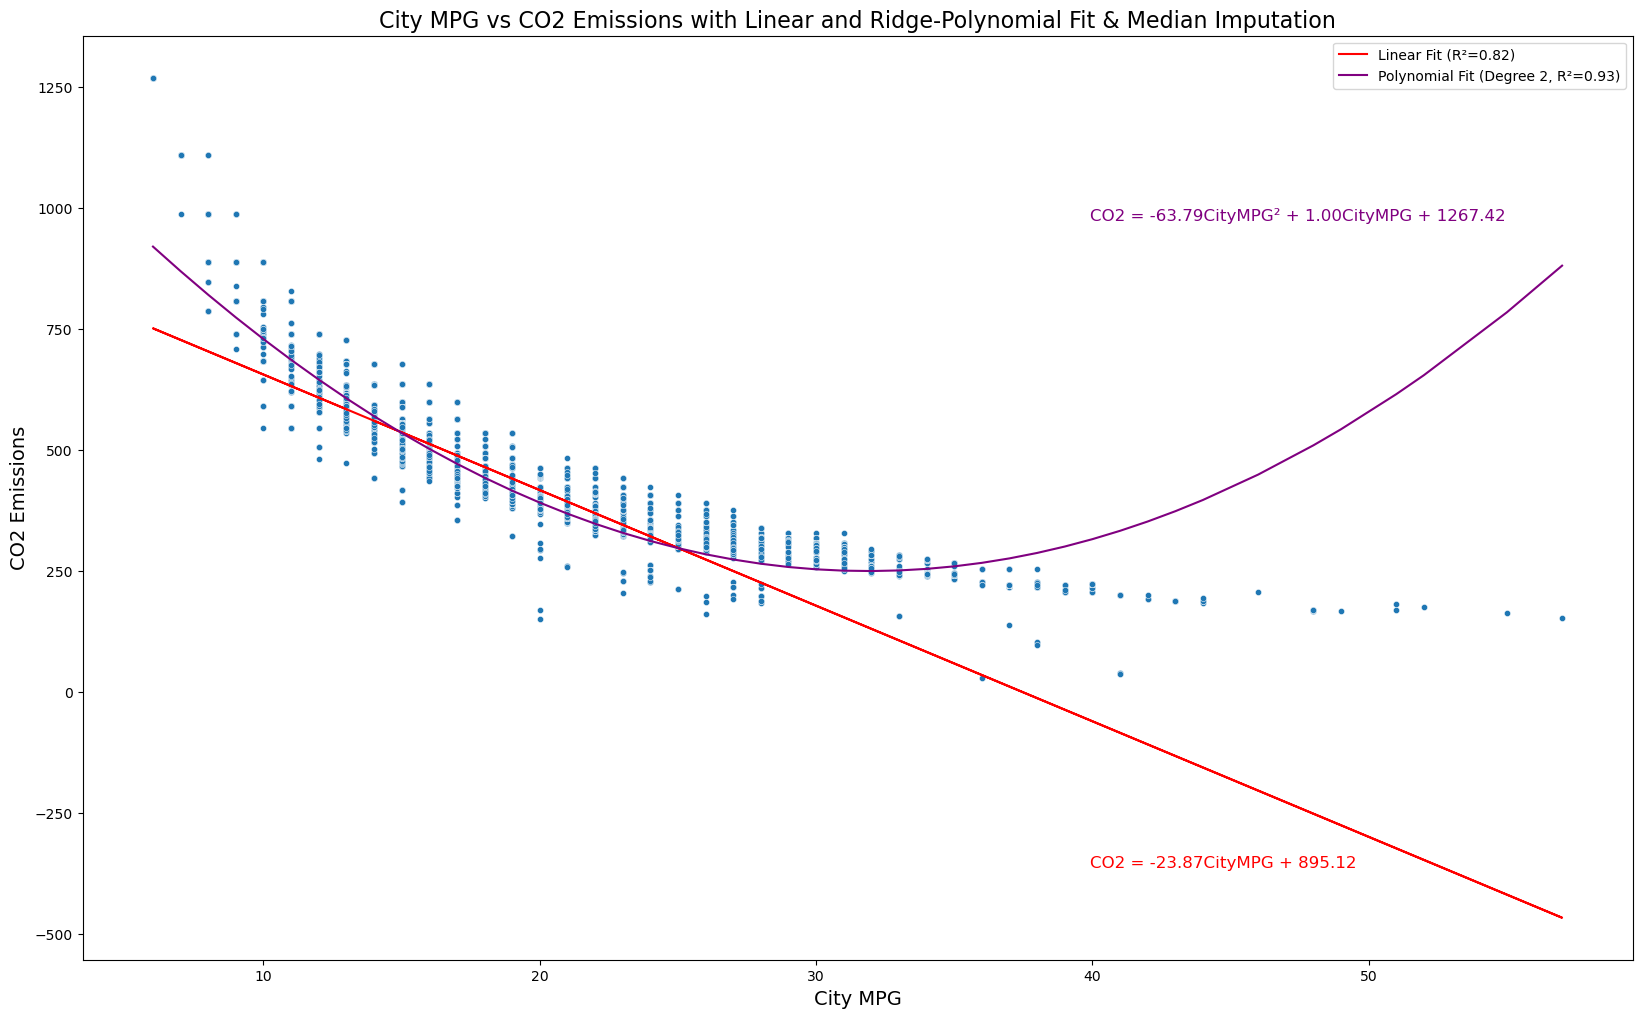

In [58]:
#Fit a line of best fit (the model) onto the scatter plot - Using Ridge Regularization and imputing with median

# Handle missing values with imputation
imputer = SimpleImputer(strategy='median')

# Apply the imputer to fill missing values in the dataset
vehicles_imputed = vehicles.copy()

# Apply imputer to numerical columns
numerical_columns = vehicles_imputed.select_dtypes(include=['float64', 'int64']).columns
vehicles_imputed[numerical_columns] = imputer.fit_transform(vehicles_imputed[numerical_columns])

plt.figure(figsize=(20, 12))  # Set the figure size before plotting

# Scatter plot
sns.scatterplot(data=vehicles_imputed, x='citympg', y='co2emissions', palette='Set1', s=20)

# Fit a Linear Regression Model
linear_model = LinearRegression()
linear_model.fit(vehicles_imputed[['citympg']], vehicles_imputed['co2emissions'])
vehicles_imputed['linear_pred'] = linear_model.predict(vehicles_imputed[['citympg']])
linear_r2 = r2_score(vehicles_imputed['co2emissions'], vehicles_imputed['linear_pred'])

# Extract linear model coefficients
linear_slope = linear_model.coef_[0]
linear_intercept = linear_model.intercept_

# Fit a Polynomial Regression Model (degree 2) with Lasso regularization
poly_degree = 2
poly_model = make_pipeline(PolynomialFeatures(degree=poly_degree), Ridge(alpha=0.1))
poly_model.fit(vehicles_imputed[['citympg']], vehicles_imputed['co2emissions'])
vehicles_imputed['poly_pred'] = poly_model.predict(vehicles_imputed[['citympg']])
poly_r2 = r2_score(vehicles_imputed['co2emissions'], vehicles_imputed['poly_pred'])

# Extract polynomial coefficients
lasso_coeffs = poly_model.named_steps['ridge'].coef_
lasso_intercept = poly_model.named_steps['ridge'].intercept_

# Polynomial equation: y = ax² + bx + c
a, b = lasso_coeffs[1], lasso_coeffs[2]
c = lasso_intercept

# Sort x-values for smoother polynomial plotting
sorted_indices = np.argsort(vehicles_imputed['citympg'])
sorted_x = vehicles_imputed['citympg'].iloc[sorted_indices]
sorted_poly_pred = vehicles_imputed['poly_pred'].iloc[sorted_indices]

# Plot linear fit
plt.plot(vehicles_imputed['citympg'], vehicles_imputed['linear_pred'], color='red', label=f'Linear Fit (R²={linear_r2:.2f})')

# Plot polynomial fit with sorted x-values (Lasso)
plt.plot(sorted_x, sorted_poly_pred, color='purple', label=f'Polynomial Fit (Degree {poly_degree}, R²={poly_r2:.2f})')

# 📌 Add Equations to the Plot
equation_linear = f'CO2 = {linear_slope:.2f}CityMPG + {linear_intercept:.2f}'
equation_poly = f'CO2 = {a:.2f}CityMPG² + {b:.2f}CityMPG + {c:.2f}'

plt.text(0.65, 0.10, equation_linear, transform=plt.gca().transAxes, fontsize=12, color='red')
plt.text(0.65, 0.80, equation_poly, transform=plt.gca().transAxes, fontsize=12, color='purple')

# Add title and labels
plt.title('City MPG vs CO2 Emissions with Linear and Ridge-Polynomial Fit & Median Imputation', fontsize=16)
plt.xlabel('City MPG', fontsize=14)
plt.ylabel('CO2 Emissions', fontsize=14)
plt.legend()

# Show plot
plt.show()

#### Advanced Relationship Visualization

Consider correlation heatmaps, collinearity checks etc.

In [25]:
#Correlation Heatmap
# 1. Label encode the 'drive' column (as it has an inherent order)
#le = LabelEncoder()
#vehicles['drive'] = le.fit_transform(vehicles['drive'])

# 2. One-Hot Encoding for the nominal categorical columns: 'make', 'model', 'class'
#vehicles_encoded = pd.get_dummies(vehicles, columns=['make', 'model', 'class','transmissiontype'], drop_first=True)

# 3. Calculate the correlation matrix
#correlation_matrix = vehicles_encoded.corr()

# Display the correlation matrix
#print(correlation_matrix)

# Optional: Visualize the correlation matrix using a heatmap
#plt.figure(figsize=(12, 10))
#sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
#plt.title('Correlation Matrix')
#plt.show()

### Distribution Visualization

#### Histogram Visualization

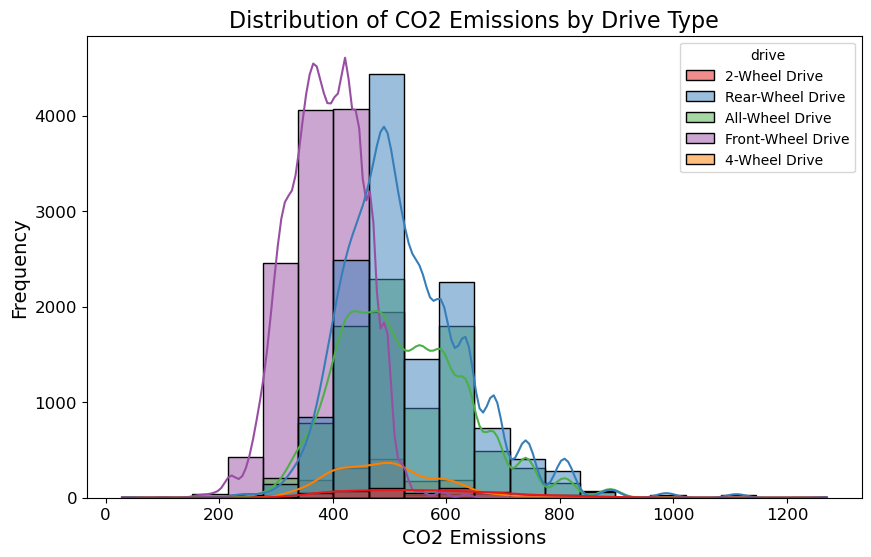

In [ ]:
# Plot histogram of 'co2emissions' with hue based on 'drive'
plt.figure(figsize=(10, 6))
sns.histplot(data=vehicles, x='co2emissions', hue='drive', bins=20, kde=True, palette='Set1', edgecolor='black')

# Add title and labels
plt.title('Distribution of CO2 Emissions by Drive Type', fontsize=16)
plt.xlabel('CO2 Emissions', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

# Optionally, adjust tick label sizes
plt.tick_params(axis='both', labelsize=12)

# Show plot
plt.show()

#### Skewness and Kurtosis Analysis

##### Definitions

Skewness and Kurtosis:

* Skew(data): Computes the skewness of the distribution. **Positive skew** means the distribution has a **long right tail**, and **negative skew** means a **long left tail**.
* Kurtosis(data): Computes the kurtosis, which indicates how heavy the tails of the distribution are. A kurtosis value **around 3** indicates a **normal distribution**, while values above or below indicate heavy or light tails, respectively.

Classification Logic:

* If the skew is greater than 1, it's classified as "Right Skewed".
* If the skew is less than -1, it's classified as "Left Skewed".
* Otherwise, it's considered "Symmetric (Approximately Normal)".
* Similarly, the kurtosis is used to describe the "tailedness" of the distribution.

Example Outputs would be:

* Right Skewed (Positively Skewed): If the histogram has a long right tail.
* Left Skewed (Negatively Skewed): If the histogram has a long left tail.
* Symmetric (Approximately Normal): If the histogram is roughly bell-shaped.
* High Kurtosis: If the distribution has heavy tails and a high number of outliers.
* Low Kurtosis: If the distribution is flat with fewer outliers.

##### Skewness and Kurtosis Impact

Skewness and kurtosis are important statistical features that can have a significant impact on your subsequent data analysis processes. The way your data is distributed can guide you in choosing the right statistical measures and modeling techniques. Here’s how skewness and kurtosis influence decisions like whether to use means or medians, and which regression models to apply:

**Skewness**
Skewness refers to the asymmetry of a data distribution. If the distribution is skewed, it means that one tail is longer or fatter than the other.

- **Positive Skew (Right Skew)**: The right tail (larger values) is longer than the left. For example, income or sales data often exhibits right skew. In this case, most data points are clustered on the left, but there are some very large values on the right.
  
- **Negative Skew (Left Skew)**: The left tail (smaller values) is longer than the right. This might occur in cases like age at death in certain populations, where most people live long lives, but there are a few who die very early.
  
- **Symmetric Distribution (Near Zero Skew)**: If the data is symmetric, it is likely close to a normal distribution.

**How Skewness Affects Subsequent Analyses**:
- **Choosing Between Mean and Median**:
  - **Right Skew**: The mean will be greater than the median because it is pulled towards the larger values in the right tail. In this case, it might be better to use the **median** to describe the central tendency, as it is less affected by extreme values (outliers).
  - **Left Skew**: The mean will be smaller than the median. Again, the **median** might be preferred to avoid the influence of extreme low values.
  - **Symmetric Distribution**: If the data is symmetric (close to normal), the **mean** and **median** will be similar, and using the **mean** is appropriate for descriptive statistics.

- **Choosing Regression Models**:
  - **Linear Regression**: Linear regression models assume that the data is normally distributed, and they are sensitive to skewed data. If your dependent variable or any predictors are highly skewed, linear regression might not work well unless the data is transformed.
  - **Transforming Data**: If your data is heavily skewed, a common approach is to apply a transformation (e.g., log transformation for right-skewed data) to make the distribution more symmetric, which can improve the model’s performance.
  - **Generalized Linear Models (GLMs)**: If transformation is not possible or not effective, GLMs with appropriate link functions (e.g., log link for count data or Poisson regression) can handle skewed data more robustly.

- **Outliers**: In the presence of skewed data, outliers have a more pronounced effect on the mean. This means that your model's performance could be sensitive to outliers, which may lead to misleading conclusions unless appropriately handled.

**Kurtosis**
Kurtosis measures the "tailedness" of a distribution — how heavy or light the tails are compared to a normal distribution. The kurtosis value for a normal distribution is around **3**. A distribution with high kurtosis has heavy tails (more outliers), while low kurtosis indicates lighter tails.

- **High Kurtosis (Leptokurtic)**: This means that the distribution has heavy tails and more extreme outliers than a normal distribution. This might occur in financial markets or in data with extreme variations.
  
- **Low Kurtosis (Platykurtic)**: This means the distribution has light tails, implying fewer extreme outliers. Data such as heights or weights often exhibit lower kurtosis.

**How Kurtosis Affects Subsequent Analyses**:
- **Choosing Between Mean and Median**:
  - **High Kurtosis (Heavy Tails)**: The presence of extreme values (outliers) can distort the mean significantly. In this case, the **median** is often a more robust measure of central tendency.
  - **Low Kurtosis (Light Tails)**: Since the distribution has fewer extreme values, the **mean** can be used effectively for analysis.

- **Choosing Regression Models**:
  - **Linear Regression**: Similar to skewness, if your data has high kurtosis (i.e., a lot of outliers), it can affect the model’s fit, causing it to underperform. It might also violate the assumption of homoscedasticity (constant variance of residuals). One approach is to **robustly estimate** the model using techniques like **Huber regression** or **quantile regression**, which are less sensitive to outliers.
  - **Outlier Detection**: For high kurtosis data, it's important to detect and manage outliers using techniques like **IQR (Interquartile Range)** or **Z-scores** to avoid their impact on your analysis.

- **Model Performance and Assumptions**:
  - If data has **high kurtosis**, some regression models might not work well because they can be overly influenced by outliers or extreme values. In these cases, you may consider models that are less sensitive to outliers, such as **robust regression** techniques.
  - **Normalizing or Transforming**: If you have high kurtosis, you may need to transform the data (e.g., log or square root transformation) to reduce the influence of extreme values and achieve better model performance.

**Practical Example: Choosing Between Mean and Median**
- **Income data**: Income often exhibits **right skew** (positive skew). The mean may be disproportionately large due to a small number of high-income individuals. In this case, **median income** is a better measure of central tendency since it is not as influenced by extreme values.
- **Test scores**: Test scores in a class might have a **normal distribution**, or near symmetric distribution. In this case, using the **mean** would be appropriate for summarizing central tendency.

**Practical Example: Choosing Regression Models**
- **Linear regression**: If your target variable (`y`) is highly skewed, you may want to transform the target (e.g., using a **logarithmic transformation** for right-skewed data) before applying linear regression. This transformation will help in achieving normality and will likely improve the model’s residuals.
- **Poisson regression**: If your outcome is a **count variable** (e.g., number of customer purchases), which often shows **positive skew**, using a **Poisson regression** or **negative binomial regression** would be a more suitable choice than linear regression, as these models can handle the skew and the count nature of the data.

**Summary of Actions Based on Skewness and Kurtosis**:
- **Skewness**:
  - If **right-skewed**, use **median** for central tendency and consider **log transformation** or other appropriate transformations.
  - If **left-skewed**, use **median** and consider transformations.
  - If **symmetric**, the **mean** is generally a good choice.
  - Use **non-parametric models** or **transformations** if skew is severe.
  
- **Kurtosis**:
  - If **high kurtosis** (heavy tails), use **median** for central tendency and be cautious about **outliers**.
  - If **low kurtosis**, the **mean** is generally safe.
  - For **high kurtosis**, consider **robust regression** techniques or model **outliers** separately.

By considering these characteristics, you can ensure that your data analysis approach is more robust and well-suited to the underlying data distribution. This will lead to more accurate and meaningful results in subsequent modeling and decision-making processes.


C:\Users\hp\AppData\Local\Temp\ipykernel_13604\436849740.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=vehicles, x='co2emissions', bins=20, kde=True, palette='Set1', edgecolor='black')


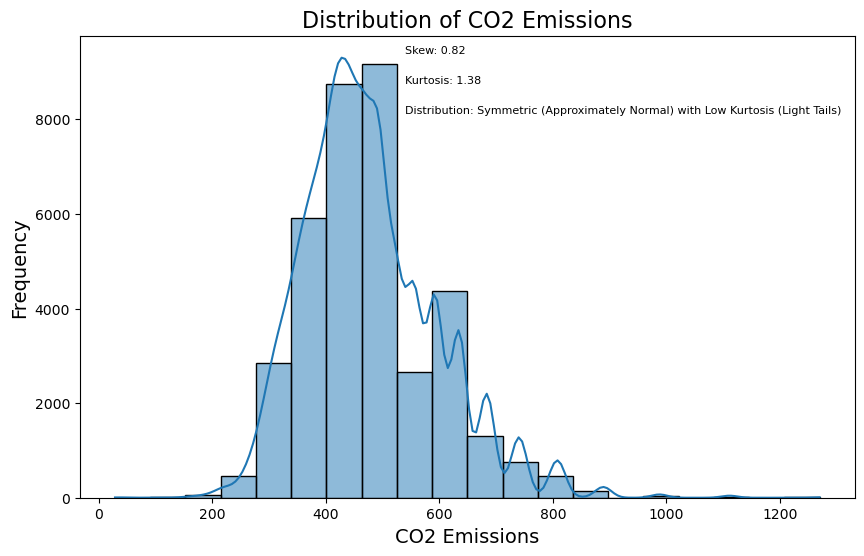

In [ ]:
#Establish the skewness and kurtosis of a particular feature and imprint it onto the histogram

skew_value = skew(vehicles['co2emissions'])
kurtosis_value = kurtosis(vehicles['co2emissions'])

# Create histogram
plt.figure(figsize=(10, 6))
sns.histplot(data=vehicles, x='co2emissions', bins=20, kde=True, palette='Set1', edgecolor='black')

# Add title and labels
plt.title('Distribution of CO2 Emissions', fontsize=16)
plt.xlabel('CO2 Emissions', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

# Add text to classify the distribution
classification = ''
if skew_value > 1:
    classification = 'Right Skewed (Positively Skewed)'
elif skew_value < -1:
    classification = 'Left Skewed (Negatively Skewed)'
else:
    classification = 'Symmetric (Approximately Normal)'

if kurtosis_value > 3:
    classification += ' with High Kurtosis (Heavy Tails)'
elif kurtosis_value < 3:
    classification += ' with Low Kurtosis (Light Tails)'
else:
    classification += ' with Normal Kurtosis'

# Display the classification on the plot
plt.figtext(0.45, 0.85, f"Skew: {skew_value:.2f}", fontsize=8, ha='left')
plt.figtext(0.45, 0.80, f"Kurtosis: {kurtosis_value:.2f}", fontsize=8, ha='left')
plt.figtext(0.45, 0.75, f"Distribution: {classification}", fontsize=8, ha='left')

# Show the plot
plt.show()

### Comparison Visualization

In [ ]:
vehicles.pivot(columns = 'drive', values = 'co2emissions')

drive,2-Wheel Drive,4-Wheel Drive,All-Wheel Drive,Front-Wheel Drive,Rear-Wheel Drive
0,555.437500,NaN,NaN,NaN,NaN
1,555.437500,NaN,NaN,NaN,NaN
2,484.761905,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,424.166667
4,NaN,NaN,NaN,NaN,555.437500
...,...,...,...,...,...
36974,NaN,NaN,NaN,NaN,442.000000
36975,NaN,NaN,NaN,NaN,466.000000
36976,NaN,NaN,NaN,NaN,503.000000
36977,NaN,NaN,NaN,NaN,661.000000


C:\Users\hp\AppData\Local\Temp\ipykernel_13604\2332849741.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=vehicles, x='drive', y='co2emissions', palette='Set2')


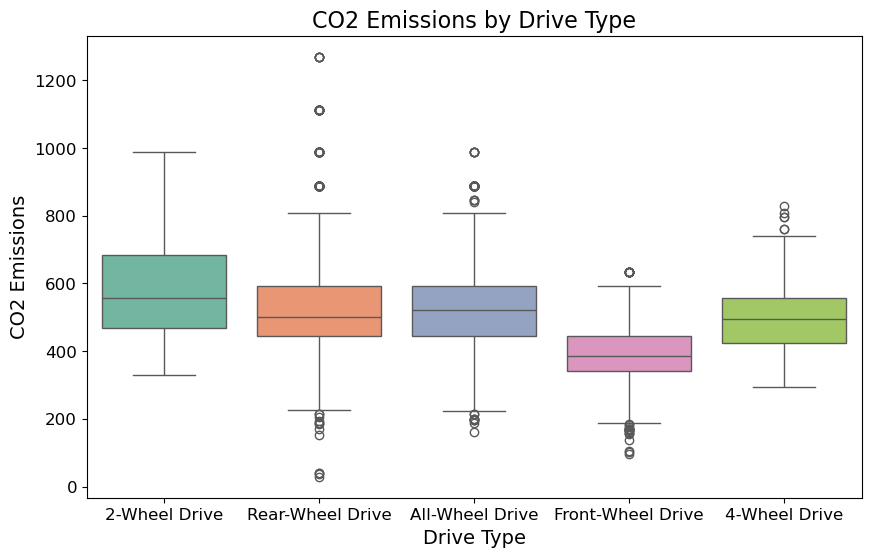

In [ ]:
# Create the box plot using Seaborn with different colors for each 'drive' category
plt.figure(figsize=(10, 6))
sns.boxplot(data=vehicles, x='drive', y='co2emissions', palette='Set2')

# Add title and axis labels
plt.title('CO2 Emissions by Drive Type', fontsize=16)
plt.xlabel('Drive Type', fontsize=14)
plt.ylabel('CO2 Emissions', fontsize=14)

# Optionally, adjust tick label sizes
plt.tick_params(axis='both', labelsize=12)

# Show plot
plt.show()

### Composition Visualization

In [ ]:
vehicles.groupby('year')['drive'].value_counts()

year  drive            
1984  2-Wheel Drive        477
      All-Wheel Drive      301
      Rear-Wheel Drive       4
1985  Rear-Wheel Drive     772
      Front-Wheel Drive    672
                          ... 
2017  4-Wheel Drive        173
2018  All-Wheel Drive      245
      Rear-Wheel Drive     230
      Front-Wheel Drive    193
      4-Wheel Drive        124
Name: count, Length: 123, dtype: int64

In [ ]:
vehicles.groupby('year')['drive'].value_counts().unstack()

drive,2-Wheel Drive,4-Wheel Drive,All-Wheel Drive,Front-Wheel Drive,Rear-Wheel Drive
year,,,,,
1984,477.0,NaN,301.0,NaN,4.0
1985,NaN,NaN,255.0,672.0,772.0
1986,NaN,1.0,202.0,430.0,576.0
1987,NaN,NaN,220.0,470.0,557.0
1988,NaN,NaN,215.0,447.0,468.0
1989,NaN,NaN,227.0,445.0,480.0
1990,NaN,NaN,241.0,422.0,413.0
1991,NaN,NaN,243.0,431.0,456.0
1992,NaN,NaN,232.0,455.0,432.0


<Axes: xlabel='year'>

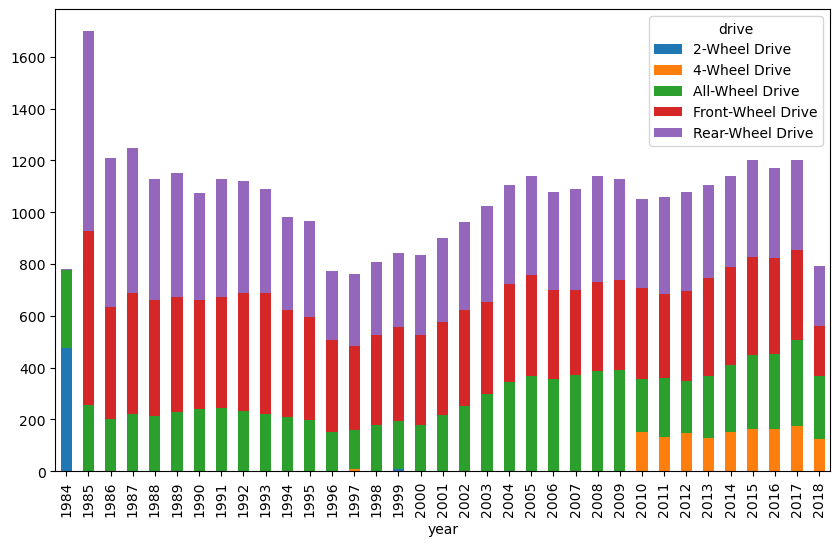

In [ ]:
vehicles.groupby('year')['drive'].value_counts().unstack().plot(kind = 'bar', 
                                                                stacked = True, 
                                                                figsize = (10, 6))

## 3. Data Preparation

### Removing Duplicates

### Handling Missing Values

### Handling Outliers

### Feature Engineering

### Feature(s) and Target(s) Selection

In [ ]:
response = 'rentals'
y = bikes[[response]]
y

,rentals
0,985
1,801
2,1349
3,1562
4,1600
...,...
726,2114
727,3095
728,1341
729,1796


In [ ]:
predictors = list(bikes.columns)
predictors.remove(response)
x = bikes[predictors]
x

,temperature,humidity,windspeed
0,46.716528,0.815969,13.669663
1,48.350239,0.800497,15.199782
2,34.212394,0.592097,13.247558
3,34.520000,0.623196,11.687963
4,36.800562,0.624643,13.148281
...,...,...,...
726,39.102528,0.482493,10.801229
727,39.031972,0.480433,8.996301
728,39.031972,0.717730,11.829425
729,39.243472,0.523039,12.805314


In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state = 1234) 

## 4. Modeling

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression().fit(x_train, y_train)

In [ ]:
model.intercept_

array([3800.68469948])

In [ ]:
model.coef_

array([[   80.35314543, -4665.73867387,  -196.21650368]])

The model coefficients correspond to the order in which the independent variables are listed in the training data. This means that the equation for the fitted regression line can be written as:

$y = 3800.68 + 80.35 \times temperature - 4665.74 \times humidity - 196.22 \times windspeed$

With the linear regression equation, we can estimate what our model will predict given any weather condition. For example, given a temperature of $72^{\circ}F$, $22\%$ humidity and windspeed of $5$ miles per hour, our model would predict:

$7,578 \text{ bikes} \approx 3800.68 + 80.35 \times 72 - 4665.74 \times .22 - 196.22 \times 5$


## 5. Evaluation

In [ ]:
model.score(x_test, y_test)

0.9820623857913312

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test, y_pred)

194.31620720519683

## 6. Actionable Insights (Conclusions and Recommendations)